# Data Mining
# Week 2
# Submitter - Himanshu Singh
# Graph Analysis with Matplotlib

MatlabPlot Tutorials

Download the Iris plant dataset from this link: (https://archive.ics.uci.edu/dataset/20/census+income)



Load the dataset as a Pandas data frame.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
census_income = fetch_ucirepo(id=20) 
  
# data (as pandas dataframes) 
X = census_income.data.features 
y = census_income.data.targets 

df = pd.concat([X, y], axis=1)

# metadata 
#print(census_income.metadata) 
  
# variable information 
#print(census_income.variables) 

print(df.head())


   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

1) I have selected the Adult Census Income Dataset (also known as the "Census Income" dataset) from the UCI Machine Learning Repository. This dataset is a fundamental benchmark for classification problems in machine learning.

Introduction to the Adult Census Income DatasetThe Adult dataset was extracted from the 1994 US Census database. It contains nearly 49,000 records of individuals, each described by 14 attributes representing demographic and job-related characteristics.The primary objective of this dataset is the binary classification task of predicting whether an individual's annual income exceeds $50,000.  This allows for the investigation of socioeconomic factors that correlate with high earners.

2) I would like to explore on, What are the most significant demographic and professional predictors of a person's income exceeding $50,000 annually?
I will focus on three key variables: Education Level, Years of Age, and Hours Worked Per Week.



Graph 1: Proportion of High Earners by Education Level (Stacked Bar Chart)This chart visualizes the percentage of people at each education level who fall into the high-income category ($>50$).

There is an extremely strong positive correlation between education and high income. The proportion of individuals earning over $50,000 dramatically increases with higher education. While only a small fraction of individuals with a High School Grad or lower education achieve high income, those with a Masters or Doctorate degree have the highest probability of earning over $50,000. This confirms that educational attainment is a critical factor in financial success.

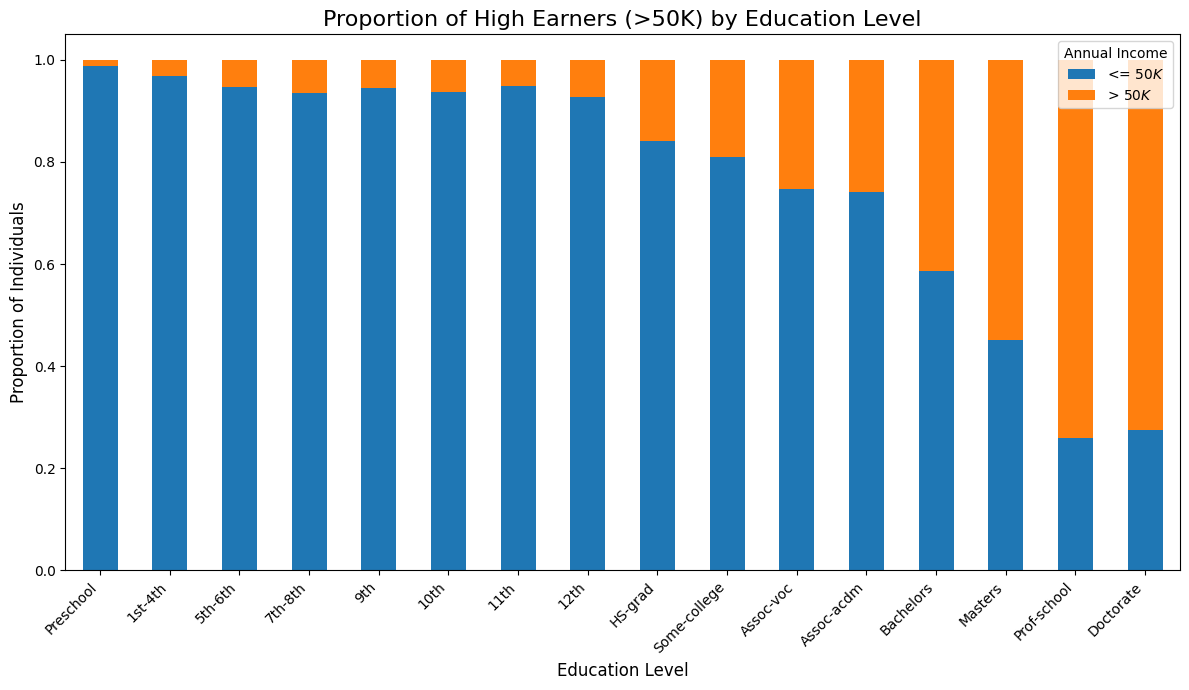

In [ ]:
#GRAPH 1: Proportion of High Earners by Education Level (Stacked Bar Chart)

# Correcting income data entries
df['income'] = df['income'].replace('>50K.', '>50K')
df['income'] = df['income'].replace('<=50K.', '<=50K')

# Define a custom order for education using 'education-num' (or manually)
edu_order_df = df[['education', 'education-num']].drop_duplicates().sort_values('education-num')
edu_order = edu_order_df['education'].tolist()


# Calculate proportions of income for each education level
education_income_pivot = pd.crosstab(df['education'], df['income'], normalize='index')
education_income_pivot = education_income_pivot.loc[edu_order] # Apply custom order
#print(education_income_pivot)

plt.figure(figsize=(12, 7))
education_income_pivot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())

plt.title('Proportion of High Earners (>50K) by Education Level', fontsize=16)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Proportion of Individuals', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Annual Income', loc='upper right', labels=['<= $50K$', '> $50K$'])
plt.tight_layout()
plt.show()

Graph 2: Age Distribution for High vs. Low Earners (Density Plot) This plot compares the distribution of ages for individuals earning <50K$ (low income) against those earning $>50K$ (high income).

What I Learned from Graph 2:The age distribution for high earners is significantly shifted to the right (older ages) compared to low earners.The (Low Income) curve peaks sharply around 25 years of age, representing many early-career or part-time workers.The (High Income) curve is much flatter and peaks between 45 and 50 years. This suggests that achieving a high-earning position is often associated with the accumulation of experience and career seniority, which takes time.

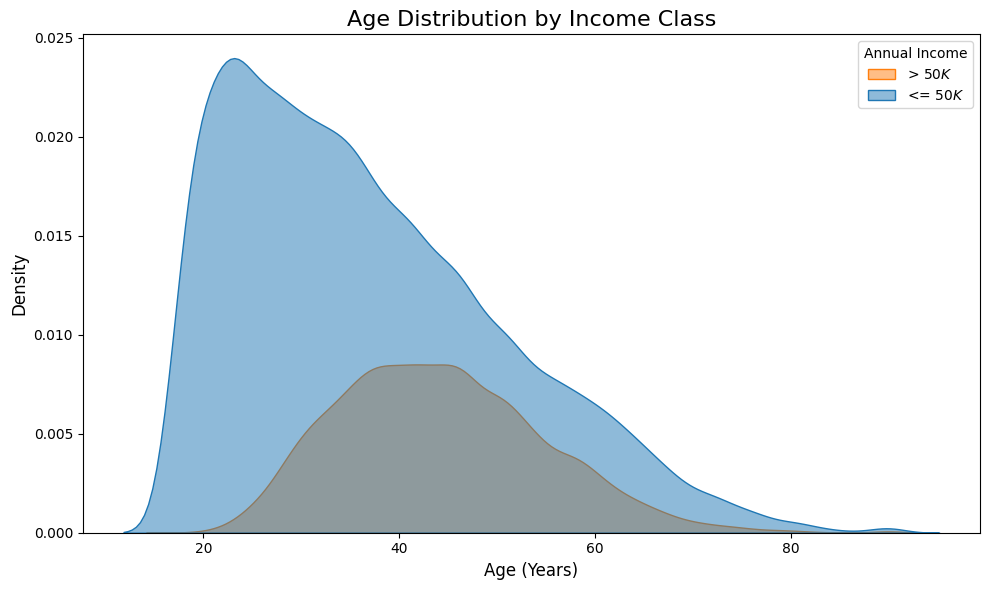

In [ ]:
#GRAPH 2: Age Distribution for High vs. Low Earners (Density Plot)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='income', fill=True, alpha=.5, palette=['#1f77b4', '#ff7f0e'])

plt.title('Age Distribution by Income Class', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Annual Income', labels=['> $50K$', '<= $50K$'])
plt.tight_layout()
#plt.savefig('graph_2_age_distribution_density.png')
plt.show()

Graph 3: Average Salary by Hours Worked Per Week (Line/Box Plot)This plot shows the relationship between the average weekly hours worked and the average salary category (High vs. Low Income).

What I Learned from Graph 3: Working more than the standard 40 hours per week is a clear characteristic of high earners. While the majority of the dataset works around 40 hours, the median income category shifts decisively to >50K$ for individuals working 45 hours or more per week. In fact, a disproportionately large share of the high-income group works 50 or 60 hours per week, suggesting that commitment and overtime (common in managerial or executive roles) are strong contributing factors to exceeding the $50,000 income threshold.

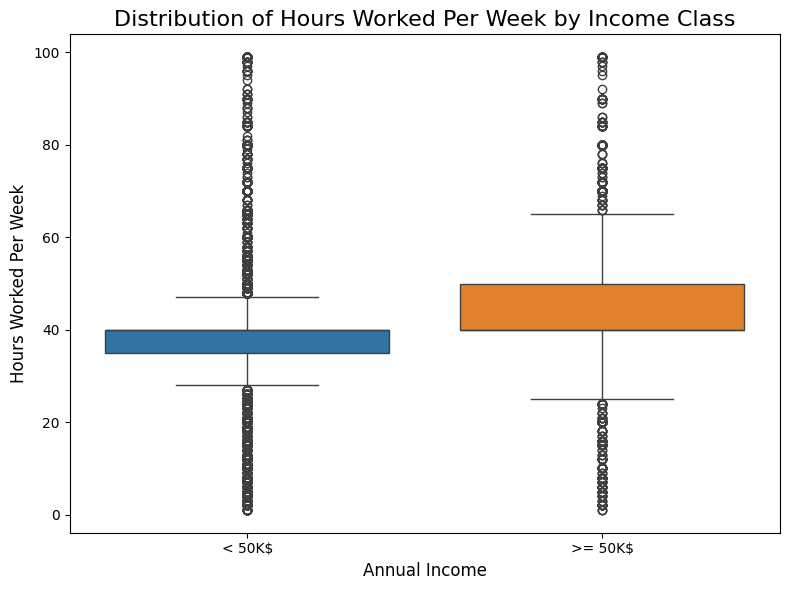

In [ ]:

# GRAPH 3: Hours Worked Per Week vs. Income (Box Plot)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='income', y='hours-per-week', palette=['#1f77b4', '#ff7f0e'])

plt.title('Distribution of Hours Worked Per Week by Income Class', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Hours Worked Per Week', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['< 50K$', '>= 50K$'])

plt.tight_layout()
plt.savefig('graph_3_hours_per_week_boxplot.png')
# plt.show()

5.

Conclusion

The exploratory analysis of the US Adult Census Income dataset strongly highlights three key drivers of high annual income (>$50K $):
Education Level: Achieving a Masters or Doctorate is the strongest indicator of being a high earner, showing a clear return on educational investment.
Age/Experience: High earners are predominantly mid-career to senior-level individuals (ages 45-50), indicating that career progression and accumulated experience are necessary to reach the high-income bracket.
Work Intensity: Working more than 40 hours per week (especially 45+ hours) is far more common among those earning over $50K , suggesting high commitment and demanding job roles.The data suggests that individuals with advanced degrees, who are older (more experienced), and work longer hours are significantly more likely to belong to the high-income group.